In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

perfil_compradores = r"C:\MBA_DC_13\mba_ia_unifor_13\praticas\projeto_final\projeto_09\data\projeto_09_compradores_perfil.csv"

preços_bairro = r"C:\MBA_DC_13\mba_ia_unifor_13\praticas\projeto_final\projeto_09\data\projeto_09_historico_precos_bairro.csv"

mercado_imobiliario = r"C:\MBA_DC_13\mba_ia_unifor_13\praticas\projeto_final\projeto_09\data\projeto_09_mercado_imobiliario.csv"



In [5]:
df_compradores = pd.read_csv(perfil_compradores, delimiter=',')

print('\n Exibindo perfil de compradores\n')
print(df_compradores.head())


 Exibindo perfil de compradores

  comprador_id  renda_mensal_declarada  idade estado_civil    profissao  \
0    CPF-03931                 8015.56     46       Casado     Advogado   
1    CPF-07445                 4047.78     55   Divorciado     Servidor   
2    CPF-01663                 8790.44     55       Casado   Empresário   
3    CPF-04479                 8191.80     61       Casado  Comerciante   
4    CPF-02381                 9396.28     45       Casado       Médico   

   numero_imoveis_adquiridos  possui_restricao_credito  pep  
0                          1                         0    0  
1                          1                         0    0  
2                          1                         0    0  
3                          2                         0    0  
4                          1                         0    1  


In [6]:

df_preços_bairros = pd.read_csv(preços_bairro, delimiter=',')

print('\n Exibindo preços dos bairros\n')
print(df_preços_bairros.head())




 Exibindo preços dos bairros

     bairro   ano  trimestre  preco_m2_referencia  numero_transacoes  \
0  Meireles  2022          1             11983.07                 75   
1  Meireles  2022          2             12482.67                 30   
2  Meireles  2022          3             11604.47                 22   
3  Meireles  2022          4             11762.33                 60   
4  Meireles  2023          1             12168.42                 13   

   variacao_trimestral_pct  
0                     -1.9  
1                      2.2  
2                      0.4  
3                      2.6  
4                      1.5  


In [7]:
df_mercado_imobiliario = pd.read_csv(mercado_imobiliario, delimiter=',')

# substituindo nulos por 0 e tranformando campo em inteiro
df_mercado_imobiliario["dias_no_mercado"] = (df_mercado_imobiliario["dias_no_mercado"].fillna(0).astype(int))
# verifica se nao é nulo, caso nao seja retorna SIM
df_mercado_imobiliario["comprador_cnpj"] = df_mercado_imobiliario["comprador_cnpj"].notna().map({True: "sim", False: "nao"})

print('\n Exibindo mercado imobiliario\n')
print(df_mercado_imobiliario.head())




 Exibindo mercado imobiliario

  transacao_id  imovel_id     bairro  tipo_imovel  area_m2  quartos condicao  \
0     TX-00001  IMO-00001     Centro  Apartamento       92        3    Usado   
1     TX-00002  IMO-00002  Messejana    Cobertura      215        3    Usado   
2     TX-00003  IMO-00003  Parangaba  Apartamento       62        3     Novo   
3     TX-00004  IMO-00004  Maracanaú  Apartamento       53        2    Usado   
4     TX-00005  IMO-00005  Maraponga  Apartamento       70        3     Novo   

   preco_total  preco_m2 comprador_id comprador_cnpj forma_pagamento  \
0    418313.16   4546.88    CPF-02925            nao         À vista   
1    736733.31   3426.67    CPF-02069            nao   Financiamento   
2    295173.19   4760.86    CPF-02157            nao   Financiamento   
3    153461.20   2895.49    CPF-03428            nao   Financiamento   
4    331702.68   4738.61    CPF-00673            nao         À vista   

   ano_transacao  mes_transacao  dias_no_mercado  
0  

In [8]:
df_consolidado = pd.merge(df_compradores,df_mercado_imobiliario, on='comprador_id', how = 'inner')

print(df_consolidado.head())


  comprador_id  renda_mensal_declarada  idade estado_civil    profissao  \
0    CPF-03931                 8015.56     46       Casado     Advogado   
1    CPF-07445                 4047.78     55   Divorciado     Servidor   
2    CPF-01663                 8790.44     55       Casado   Empresário   
3    CPF-04479                 8191.80     61       Casado  Comerciante   
4    CPF-02381                 9396.28     45       Casado       Médico   

   numero_imoveis_adquiridos  possui_restricao_credito  pep transacao_id  \
0                          1                         0    0     TX-01622   
1                          1                         0    0     TX-02830   
2                          1                         0    0     TX-00129   
3                          2                         0    0     TX-01609   
4                          1                         0    1     TX-03457   

   imovel_id  ... area_m2 quartos  condicao  preco_total  preco_m2  \
0  IMO-01622  ...     

In [9]:
#agrupa bairro-preço e traz a media de preço por bairro
media_por_bairro = df_preços_bairros.groupby("bairro")["preco_m2_referencia"].mean().reset_index()
#transforma preço para float
media_por_bairro["preco_m2_referencia"] = media_por_bairro["preco_m2_referencia"].astype(float)
#cruza base de compradores com a media de preço por bairro
df_master = pd.merge(df_consolidado, media_por_bairro, on="bairro", how="left")

print("Colunas:", df_master.columns)
print(df_master.head())

Colunas: Index(['comprador_id', 'renda_mensal_declarada', 'idade', 'estado_civil',
       'profissao', 'numero_imoveis_adquiridos', 'possui_restricao_credito',
       'pep', 'transacao_id', 'imovel_id', 'bairro', 'tipo_imovel', 'area_m2',
       'quartos', 'condicao', 'preco_total', 'preco_m2', 'comprador_cnpj',
       'forma_pagamento', 'ano_transacao', 'mes_transacao', 'dias_no_mercado',
       'preco_m2_referencia'],
      dtype='str')
  comprador_id  renda_mensal_declarada  idade estado_civil    profissao  \
0    CPF-03931                 8015.56     46       Casado     Advogado   
1    CPF-07445                 4047.78     55   Divorciado     Servidor   
2    CPF-01663                 8790.44     55       Casado   Empresário   
3    CPF-04479                 8191.80     61       Casado  Comerciante   
4    CPF-02381                 9396.28     45       Casado       Médico   

   numero_imoveis_adquiridos  possui_restricao_credito  pep transacao_id  \
0                          1  

In [10]:
df_master['variação'] = (df_master['preco_m2'] / df_master['preco_m2_referencia']) - 1

df_master['é suspeito?'] = np.where(df_master['variação'] >= 0.40,'SIM','NÃO')

df_suspeitos_sobrepreco = df_master[['transacao_id', 'comprador_id', 'bairro', 'variação','é suspeito?','profissao']]

print(df_suspeitos_sobrepreco.head(10))

print("1. Transações com Sobrepreço:")

  transacao_id comprador_id     bairro  variação é suspeito?    profissao
0     TX-01622    CPF-03931  Maraponga -0.098722         NÃO     Advogado
1     TX-02830    CPF-07445     Centro  0.063916         NÃO     Servidor
2     TX-00129    CPF-01663    Montese -0.063420         NÃO   Empresário
3     TX-01609    CPF-04479   Meireles  0.024505         NÃO  Comerciante
4     TX-03457    CPF-02381     Centro  0.485268         SIM       Médico
5     TX-01962    CPF-04945  Messejana  0.067515         NÃO     Autônomo
6     TX-02242    CPF-00561    Aldeota  0.136587         NÃO     Autônomo
7     TX-00421    CPF-02687    Benfica  0.221048         NÃO  Comerciante
8     TX-03155    CPF-00378    Eusébio  0.029737         NÃO       Médico
9     TX-00324    CPF-00385  Maraponga -0.088431         NÃO     Servidor
1. Transações com Sobrepreço:


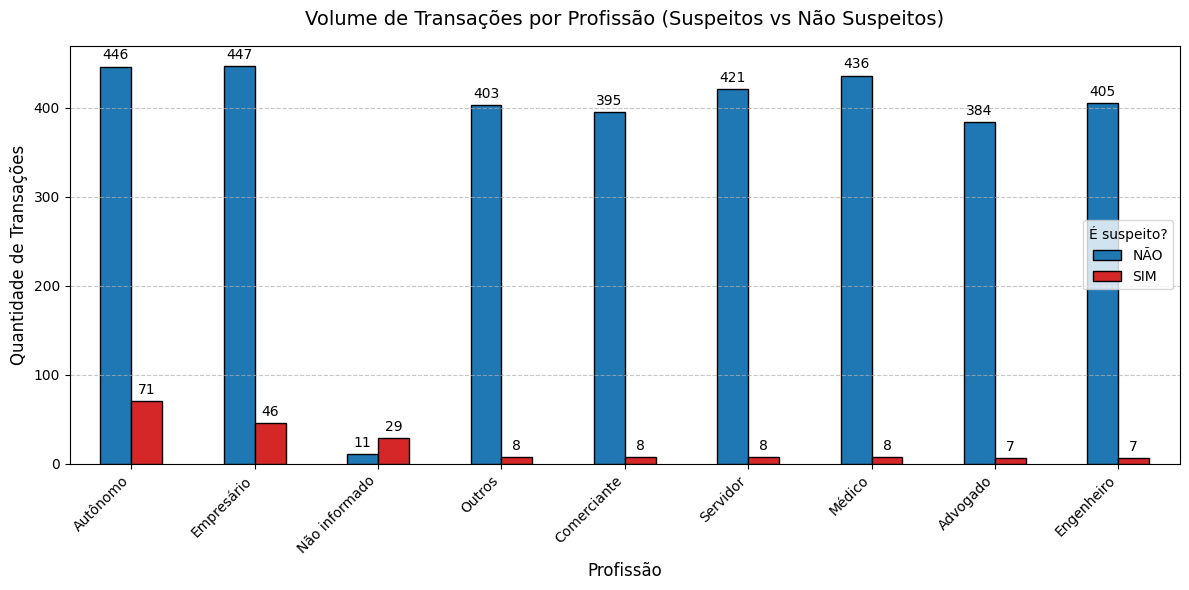

In [11]:
dados_grafico = pd.crosstab(df_master['profissao'], df_master['é suspeito?'])

# Ordena o DataFrame baseando-se na coluna 'SIM' do maior para o menor
dados_grafico = dados_grafico.sort_values(by='SIM', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
dados_grafico.plot(kind='bar', ax=ax, color=['#1f77b4', '#d62728'], edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Volume de Transações por Profissão (Suspeitos vs Não Suspeitos)', fontsize=14, pad=15)
plt.xlabel('Profissão', fontsize=12)
plt.ylabel('Quantidade de Transações', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='É suspeito?')
plt.tight_layout()

plt.show()


2. CPFs com Renda Incompatível:
     comprador_id  renda_mensal_declarada  preco_total compra_suspeita?
0       CPF-03931                 8015.56    110495.80              NÃO
1       CPF-07445                 4047.78    564654.29              NÃO
2       CPF-01663                 8790.44    527718.19              NÃO
3       CPF-04479                 8191.80    258916.93              NÃO
4       CPF-02381                 9396.28    514095.46              NÃO
...           ...                     ...          ...              ...
3535    CPF-03338                 8466.55    530745.12              NÃO
3536    CPF-01373                11316.16    509178.69              NÃO
3537    CPF-01373                11316.16    971796.61              NÃO
3538    CPF-04854                 8073.48    391405.86              NÃO
3539    CPF-04770                12266.98   1066524.47              NÃO

[3540 rows x 4 columns]
  SUSPEITO?  Soma de RENDA DECLARADA  Soma de preco_total  investimento/renda


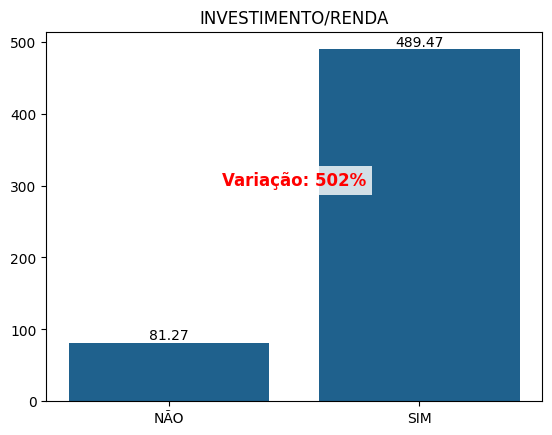

In [54]:


# suspeitos_renda = df_master[(df_master['preco_total'] >= 1000000) & (df_master['renda_mensal_declarada'] < 5000)]


df_master['compra_suspeita?'] = np.where((df_master['preco_total'] >= 1000000) & (df_master['renda_mensal_declarada'] < 5000), 'SIM', 'NÃO')


print("\n2. CPFs com Renda Incompatível:")
print(df_master[['comprador_id', 'renda_mensal_declarada', 'preco_total','compra_suspeita?']])

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

visao_suspeitos = df_master.groupby('compra_suspeita?').agg({'renda_mensal_declarada': 'sum','preco_total': 'sum'}).reset_index()

visao_suspeitos.columns = ['SUSPEITO?', 'Soma de RENDA DECLARADA', 'Soma de preco_total']

visao_suspeitos['investimento/renda'] = (visao_suspeitos['Soma de preco_total']/visao_suspeitos['Soma de RENDA DECLARADA'])

print(visao_suspeitos)

x = visao_suspeitos['SUSPEITO?']
y = visao_suspeitos['investimento/renda']

# 2. Plotagem com o azul petróleo (mesmo estilo do prompt anterior)
plt.bar(x, y, color='#1f618d')

# 3. Adicionar valores em cima das barras
for i, valor in enumerate(y):
    plt.text(i, valor, f'{valor:.2f}', ha='center', va='bottom')

# 4. Adicionar a variação de 502% entre as barras
# Posicionamos no centro (0.5) e numa altura média
plt.annotate('Variação: 502%', 
             xy=(0.5, 300), 
             ha='center', 
             fontsize=12, 
             fontweight='bold',
             color='red',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.title('INVESTIMENTO/RENDA')
plt.show()


In [ ]:
df_master['maior_3_aquisicoes?'] = np.where(df_master['numero_imoveis_adquiridos'] >= 3, 'SIM', 'NÃO')

# print(df_master[['maior_3_aquisicoes?','numero_imoveis_adquiridos']].head(20))

# print(df_master.columns)

# visao_profissao = df_master.groupby('profissao').agg({'maior_3_aquisicoes?': 'count'}).reset_index()

# visao_profissao = df_master.groupby(['profissao', 'maior_3_aquisicoes?']).size().unstack(fill_value=0)
visao_profissao = df_master.groupby(['profissao', 'maior_3_aquisicoes?'])['comprador_id'].nunique().unstack(fill_value=0)

print(visao_profissao)



maior_3_aquisicoes?  NÃO  SIM
profissao                    
Advogado             323    0
Autônomo             351   10
Comerciante          331    0
Empresário           344    6
Engenheiro           334    0
Médico               363    0
Não informado          0    4
Outros               331    0
Servidor             334    0


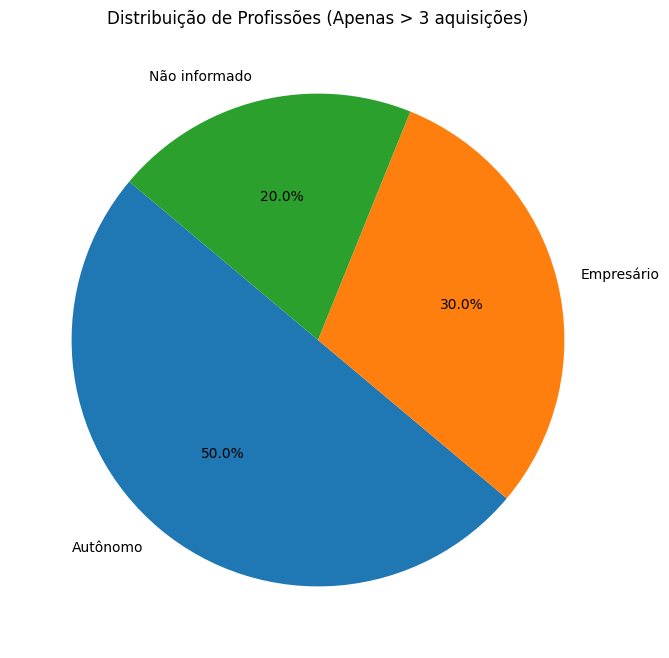

In [62]:
dados_sim = visao_profissao['SIM'][visao_profissao['SIM'] > 0]

# 2. Criar o gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(
    dados_sim, 
    labels=dados_sim.index, 
    autopct='%1.1f%%', 
    startangle=140
)

plt.title('Distribuição de Profissões (Apenas > 3 aquisições)')
plt.show()

In [83]:
contagem_imovel = df_master.groupby('imovel_id')['imovel_id'].transform('count')

# 2. Se o imóvel aparecer mais que 2 vezes, recebe 'SIM', caso contrário 'NÃO'
df_master['varias_transacoes'] = np.where(contagem_imovel > 2, 'SIM', 'NÃO')

print(contagem_imovel.sort_values())

16      1
3521    1
3522    1
3523    1
3524    1
       ..
1886    3
293     4
309     4
739     4
2689    4
Name: imovel_id, Length: 3540, dtype: int64
